# 07: NODE PREDICTION

This notebook applies the trained XGBoost deployment model to predict Land Surface Temperature at all network nodes for heat-weighted routing.

## MODULE SETUP

In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

MODEL_DIR = Path("models")
DIAGNOSTICS_DIR = MODEL_DIR / "diagnostics"

print(f"Working directory: {BASE_DIR}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [2]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## PATH CONFIGURATION

In [3]:
# Input paths.
NODES_FILE = Path("data/outputs/features/network_nodes_with_raster_features.csv")
MODEL_FILE = Path("models/xgboost_deployment_model.pkl")
TRAIN_FILE = Path("data/outputs/features/gsv_with_raster_features.csv")

# Output path.
OUT_DIR = Path("data/outputs/predictions")
OUT_FILE = OUT_DIR / "network_nodes_with_predictions.csv"

# Create output directory.
OUT_DIR.mkdir(parents = True, exist_ok = True)

print("PATH CONFIGURATION")
print(f"Network nodes: {NODES_FILE}")
print(f"Model file: {MODEL_FILE}")
print(f"Training data: {TRAIN_FILE}")
print(f"Output file: {OUT_FILE}")

PATH CONFIGURATION
Network nodes: data/outputs/features/network_nodes_with_raster_features.csv
Model file: models/xgboost_deployment_model.pkl
Training data: data/outputs/features/gsv_with_raster_features.csv
Output file: data/outputs/predictions/network_nodes_with_predictions.csv


## LOAD MODEL

In [4]:
# Load trained deployment model.
with open(MODEL_FILE, "rb") as f:
    model_data = pickle.load(f)

model = model_data["model"]
features = model_data["features"]
target = model_data["target"]
cv_rmse = model_data["cv_rmse"]
cv_r2 = model_data["cv_r2"]

print("MODEL DETAILS")
print(f"Target variable: {target}")
print(f"Number of features: {len(features)}")
print(f"Cross-validation RMSE: {cv_rmse:.4f}")
print(f"Cross-validation R2: {cv_r2:.4f}")
print("")
print("Required features:")
for i, feat in enumerate(features, 1):
    print(f"{i:2d}. {feat}")

MODEL DETAILS
Target variable: lst_celsius
Number of features: 11
Cross-validation RMSE: 1.1570
Cross-validation R2: 0.4036

Required features:
 1. ndvi
 2. emissivity
 3. palsar_hh_db
 4. palsar_hv_db
 5. palsar_hv_hh_ratio
 6. palsar_glcm_contrast
 7. palsar_glcm_homogeneity
 8. palsar_glcm_energy
 9. elevation_m
10. sky_view_factor
11. landcover_class


## LOAD NETWORK NODES

In [5]:
# Load network nodes with features.
df_nodes = pd.read_csv(NODES_FILE)

print(f"Loaded {len(df_nodes)} network nodes.")
print(f"Columns: {list(df_nodes.columns)}")
df_nodes.head()

Loaded 28445 network nodes.
Columns: ['osmid', 'y', 'x', 'street_count', 'highway', 'ref', 'railway', 'geometry', 'lon', 'lat', 'lst_kelvin', 'lst_celsius', 'ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


,osmid,y,x,street_count,highway,ref,railway,geometry,lon,lat,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,366367367,10.813901,106.732449,1,NaN,NaN,NaN,POINT (106.7324492 10.8139013),106.732449,10.813901,...,2.7385,-6.660599,-10.774033,1.617577,6199.80,0.031244,0.158114,10.0,0.999971,2.0
1,366368182,10.742144,106.670913,3,NaN,NaN,NaN,POINT (106.6709134 10.7421444),106.670913,10.742144,...,2.6601,2.644283,-11.333757,-4.286137,3650.35,0.008234,0.165831,9.0,0.998736,2.0
2,366368194,10.790241,106.709544,3,NaN,NaN,NaN,POINT (106.7095438 10.7902412),106.709544,10.790241,...,2.7238,5.584384,-0.062562,-0.011203,2781.00,0.007803,0.158114,7.0,0.993674,2.0
3,366368313,10.754628,106.684140,4,NaN,NaN,NaN,POINT (106.6841396 10.7546276),106.684140,10.754628,...,2.7826,3.691487,-10.945781,-2.965141,3170.60,0.107993,0.165831,12.0,0.999859,2.0
4,366368540,10.742907,106.672759,4,NaN,NaN,NaN,POINT (106.6727592 10.742907),106.672759,10.742907,...,2.6605,7.113308,-10.508171,-1.477255,4261.00,0.003137,0.158114,6.0,0.990122,2.0


## VERIFY FEATURES

In [6]:
# Check that all required features are available.
missing_features = [f for f in features if f not in df_nodes.columns]

if missing_features:
    print(f"WARNING: Missing features: {missing_features}")
else:
    print("All required features are available.")

# Check feature completeness.
print("")
print("FEATURE COMPLETENESS")
for feat in features:
    if feat in df_nodes.columns:
        valid = df_nodes[feat].notna().sum()
        pct = valid / len(df_nodes) * 100
        print(f"{feat:35s}: {valid:6d} ({pct:5.1f}%)")

All required features are available.

FEATURE COMPLETENESS
ndvi                               :  28445 (100.0%)
emissivity                         :  28445 (100.0%)
palsar_hh_db                       :  28445 (100.0%)
palsar_hv_db                       :  28445 (100.0%)
palsar_hv_hh_ratio                 :  28445 (100.0%)
palsar_glcm_contrast               :  28445 (100.0%)
palsar_glcm_homogeneity            :  28445 (100.0%)
palsar_glcm_energy                 :  28445 (100.0%)
elevation_m                        :  28445 (100.0%)
sky_view_factor                    :  28445 (100.0%)
landcover_class                    :  28445 (100.0%)


## PREPARE PREDICTION DATA

In [7]:
# Extract feature matrix.
X_pred = df_nodes[features].copy()

print(f"Prediction samples: {len(X_pred)}")
print(f"Features: {len(features)}")

# Check for missing values.
missing_count = X_pred.isna().any(axis = 1).sum()
print(f"Samples with missing values: {missing_count} ({missing_count/len(X_pred)*100:.1f}%)")

Prediction samples: 28445
Features: 11
Samples with missing values: 0 (0.0%)


## PREDICT LST

In [8]:
# Apply model to predict LST.
# XGBoost handles NaN values internally.
predictions = model.predict(X_pred)

# Store predictions.
df_nodes["predicted_lst_celsius"] = predictions

print("Predictions complete.")
print("")
print("Predicted LST statistics:")
print(df_nodes["predicted_lst_celsius"].describe())

Predictions complete.

Predicted LST statistics:
count    28445.000000
mean        40.644375
std          1.195996
min         37.332535
25%         39.815926
50%         40.519478
75%         40.984192
max         44.044712
Name: predicted_lst_celsius, dtype: float64


## CREATE HEAT CATEGORIES (QUANTILE-BASED)

The original fixed thresholds (<30 Cool, 30-35 Warm, 35-40 Hot, 40+ Very Hot) produced non-discriminating categories: 69.2% of nodes fell into "Very Hot" and 0% into "Cool" or "Warm", making the categories useless for routing differentiation.

Quantile-based categories (quintiles) guarantee a roughly even 20% split across five bins, producing categories that are defined relative to the study area's own predicted temperature distribution. This is more useful for routing because it distinguishes the coolest and hottest *local* options regardless of the absolute temperature range.

In [9]:
# Assign heat categories using quintiles of the predicted distribution.
# Each bin contains approximately 20% of all nodes.
quintile_labels = ["Coolest 20%", "Cool-Moderate", "Moderate", "Warm-Hot", "Hottest 20%"]

df_nodes["heat_category"] = pd.qcut(
    df_nodes["predicted_lst_celsius"],
    q = 5,
    labels = quintile_labels,
    duplicates = "drop"
)

# Report category distribution and temperature ranges.
print("HEAT CATEGORY DISTRIBUTION (QUINTILE-BASED)")
print("")
for cat in quintile_labels:
    subset = df_nodes[df_nodes["heat_category"] == cat]["predicted_lst_celsius"]
    if len(subset) > 0:
        print(f"{cat:15s}: n = {len(subset):6d} ({len(subset)/len(df_nodes)*100:5.1f}%), range = [{subset.min():.2f}, {subset.max():.2f}] C")

# Also store the quintile bin edges for reference.
_, bin_edges = pd.qcut(df_nodes["predicted_lst_celsius"], q = 5, retbins = True, duplicates = "drop")
print("")
print(f"Quintile bin edges (C): {[round(b, 2) for b in bin_edges]}")

HEAT CATEGORY DISTRIBUTION (QUINTILE-BASED)

Coolest 20%    : n =   5689 ( 20.0%), range = [37.33, 39.66] C
Cool-Moderate  : n =   5689 ( 20.0%), range = [39.66, 40.30] C
Moderate       : n =   5689 ( 20.0%), range = [40.30, 40.72] C
Warm-Hot       : n =   5689 ( 20.0%), range = [40.72, 41.24] C
Hottest 20%    : n =   5689 ( 20.0%), range = [41.24, 44.04] C

Quintile bin edges (C): [np.float64(37.33), np.float64(39.66), np.float64(40.3), np.float64(40.72), np.float64(41.24), np.float64(44.04)]


## VISUALIZE PREDICTIONS

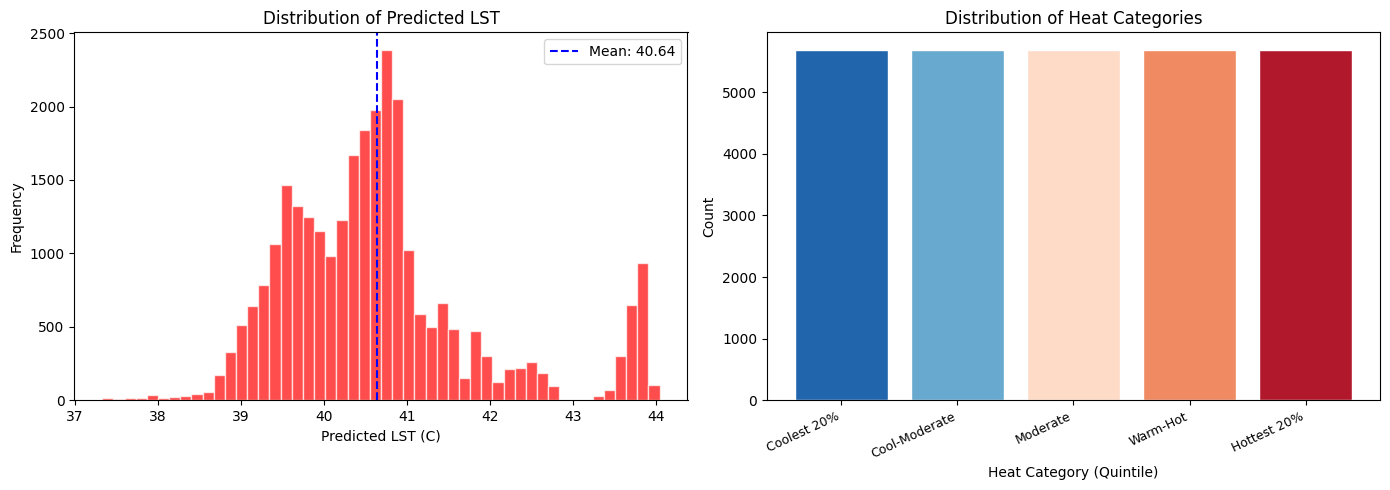

In [10]:
# Histogram of predicted LST.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# LST distribution.
axes[0].hist(df_nodes["predicted_lst_celsius"].dropna(), bins = 50, color = "red", alpha = 0.7, edgecolor = "white")
axes[0].axvline(df_nodes["predicted_lst_celsius"].mean(), color = "blue", linestyle = "--", label = f"Mean: {df_nodes['predicted_lst_celsius'].mean():.2f}")
axes[0].set_xlabel("Predicted LST (C)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Predicted LST")
axes[0].legend()

# Heat category distribution.
category_counts = df_nodes["heat_category"].value_counts().reindex(quintile_labels, fill_value = 0)
colors = ["#2166ac", "#67a9cf", "#fddbc7", "#ef8a62", "#b2182b"]

axes[1].bar(range(len(category_counts)), category_counts.values, color = colors, edgecolor = "white")
axes[1].set_xticks(range(len(category_counts)))
axes[1].set_xticklabels(quintile_labels, rotation = 25, ha = "right", fontsize = 9)
axes[1].set_xlabel("Heat Category (Quintile)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Heat Categories")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "lst_distribution.png", dpi = 300, bbox_inches = "tight")
plt.show()

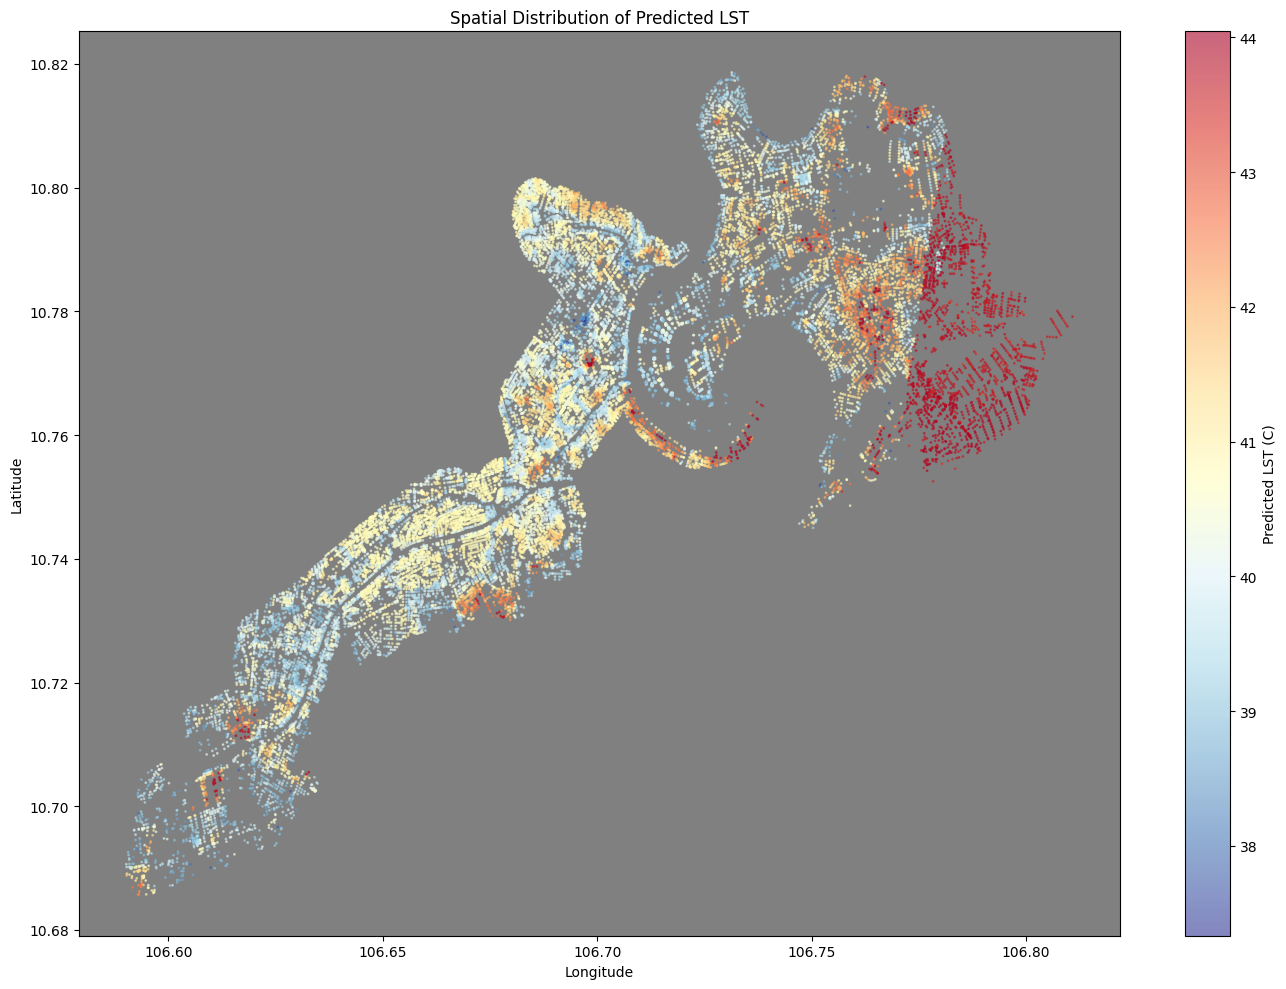

In [11]:
# Spatial distribution of predicted LST.
if "lon" in df_nodes.columns and "lat" in df_nodes.columns:
    fig, ax = plt.subplots(1, 1, figsize = (14, 10))

    ax.set_facecolor("gray")

    scatter = ax.scatter(
        df_nodes["lon"],
        df_nodes["lat"],
        c = df_nodes["predicted_lst_celsius"],
        cmap = "RdYlBu_r",
        s = 1,
        alpha = 0.6
    )

    cbar = plt.colorbar(scatter, ax = ax, label = "Predicted LST (C)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Spatial Distribution of Predicted LST")

    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "lst_spatial_distribution.png", dpi = 300, bbox_inches = "tight")
    plt.show()
else:
    print("Latitude/longitude columns not available for spatial plot.")

## COMPARE WITH OBSERVED LST

COMPARISON WITH OBSERVED LST
Samples with both observed and predicted: 28340
RMSE: 1.4206
R²: 0.5230
MAE: 0.9854


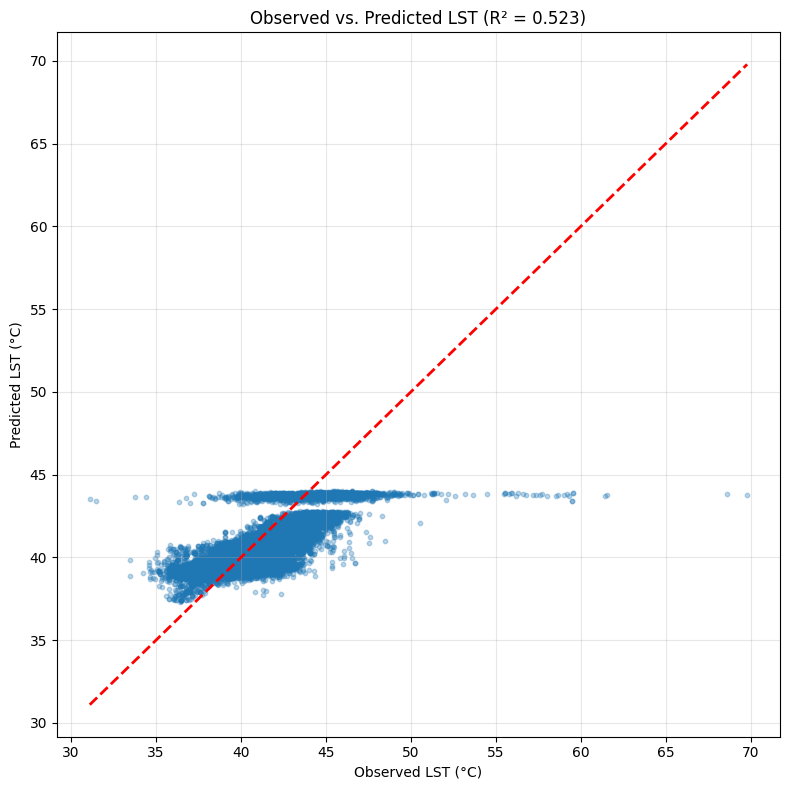

In [12]:
# Compare predicted vs observed LST where available.
if "lst_celsius" in df_nodes.columns:
    mask = df_nodes["lst_celsius"].notna() & df_nodes["predicted_lst_celsius"].notna()

    observed = df_nodes.loc[mask, "lst_celsius"]
    predicted = df_nodes.loc[mask, "predicted_lst_celsius"]

    if len(observed) > 0:
        rmse = np.sqrt(mean_squared_error(observed, predicted))
        r2 = r2_score(observed, predicted)
        mae = mean_absolute_error(observed, predicted)

        print("COMPARISON WITH OBSERVED LST")
        print(f"Samples with both observed and predicted: {len(observed)}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R\u00b2: {r2:.4f}")
        print(f"MAE: {mae:.4f}")

        # Scatter plot.
        fig, ax = plt.subplots(1, 1, figsize = (8, 8))
        ax.scatter(observed, predicted, alpha = 0.3, s = 10)
        ax.plot([observed.min(), observed.max()], [observed.min(), observed.max()], "r--", lw = 2)
        ax.set_xlabel("Observed LST (\u00b0C)")
        ax.set_ylabel("Predicted LST (\u00b0C)")
        ax.set_title(f"Observed vs. Predicted LST (R\u00b2 = {r2:.3f})")
        ax.grid(alpha = 0.3)
        plt.tight_layout()
        plt.savefig(DIAGNOSTICS_DIR / "obs_vs_pred_lst.png", dpi = 300, bbox_inches = "tight")
        plt.show()
    else:
        print("No samples with both observed and predicted LST.")
else:
    print("Observed LST column not available for comparison.")

## DISTRIBUTION COMPARISON: PREDICTED VS TRAINING DATA

Regression models can suffer from **mean-reversion** (also called regression to the mean): predictions cluster around the training mean and fail to reproduce the tails of the observed distribution. This is especially problematic for heat routing, where the coolest and hottest nodes matter most.

This section loads the original training data and compares the observed LST distribution against the predicted distribution across all network nodes. Key diagnostics:
- If the predicted range is much narrower than observed, the model is compressing the tails.
- If the predicted std is much smaller than observed std, the model under-predicts variance.
- The overlay histogram visually shows whether predictions reproduce the shape of the training distribution.

In [13]:
# Load training data for distribution comparison.
df_train = pd.read_csv(TRAIN_FILE)
train_lst = df_train["lst_celsius"].dropna()

pred_lst = df_nodes["predicted_lst_celsius"].dropna()

print("DISTRIBUTION COMPARISON")
print("")
print(f"{'Statistic':15s} {'Training (Obs)':>15s} {'Predicted (All Nodes)':>22s}")
print(f"{'Count':15s} {len(train_lst):15d} {len(pred_lst):22d}")
print(f"{'Mean':15s} {train_lst.mean():15.2f} {pred_lst.mean():22.2f}")
print(f"{'Std':15s} {train_lst.std():15.2f} {pred_lst.std():22.2f}")
print(f"{'Min':15s} {train_lst.min():15.2f} {pred_lst.min():22.2f}")
print(f"{'5th pct':15s} {train_lst.quantile(0.05):15.2f} {pred_lst.quantile(0.05):22.2f}")
print(f"{'25th pct':15s} {train_lst.quantile(0.25):15.2f} {pred_lst.quantile(0.25):22.2f}")
print(f"{'Median':15s} {train_lst.median():15.2f} {pred_lst.median():22.2f}")
print(f"{'75th pct':15s} {train_lst.quantile(0.75):15.2f} {pred_lst.quantile(0.75):22.2f}")
print(f"{'95th pct':15s} {train_lst.quantile(0.95):15.2f} {pred_lst.quantile(0.95):22.2f}")
print(f"{'Max':15s} {train_lst.max():15.2f} {pred_lst.max():22.2f}")
print(f"{'Range':15s} {train_lst.max() - train_lst.min():15.2f} {pred_lst.max() - pred_lst.min():22.2f}")
print(f"{'IQR':15s} {train_lst.quantile(0.75) - train_lst.quantile(0.25):15.2f} {pred_lst.quantile(0.75) - pred_lst.quantile(0.25):22.2f}")

# Variance ratio diagnostic.
var_ratio = pred_lst.std() / train_lst.std()
print("")
print(f"Variance ratio (pred std / train std): {var_ratio:.3f}")
if var_ratio < 0.7:
    print("WARNING: Substantial mean-reversion detected (variance ratio < 0.7).")
    print("Predictions are significantly more compressed than training observations.")
elif var_ratio < 0.9:
    print("CAUTION: Moderate mean-reversion (variance ratio 0.7-0.9).")
else:
    print("OK: Predicted variance is comparable to training variance.")

DISTRIBUTION COMPARISON

Statistic        Training (Obs)  Predicted (All Nodes)
Count                     20402                  28445
Mean                      40.46                  40.64
Std                        1.55                   1.20
Min                       33.46                  37.33
5th pct                   37.63                  39.11
25th pct                  39.52                  39.82
Median                    40.60                  40.52
75th pct                  41.45                  40.98
95th pct                  42.76                  43.68
Max                       46.54                  44.04
Range                     13.08                   6.71
IQR                        1.94                   1.17

Variance ratio (pred std / train std): 0.771
CAUTION: Moderate mean-reversion (variance ratio 0.7-0.9).


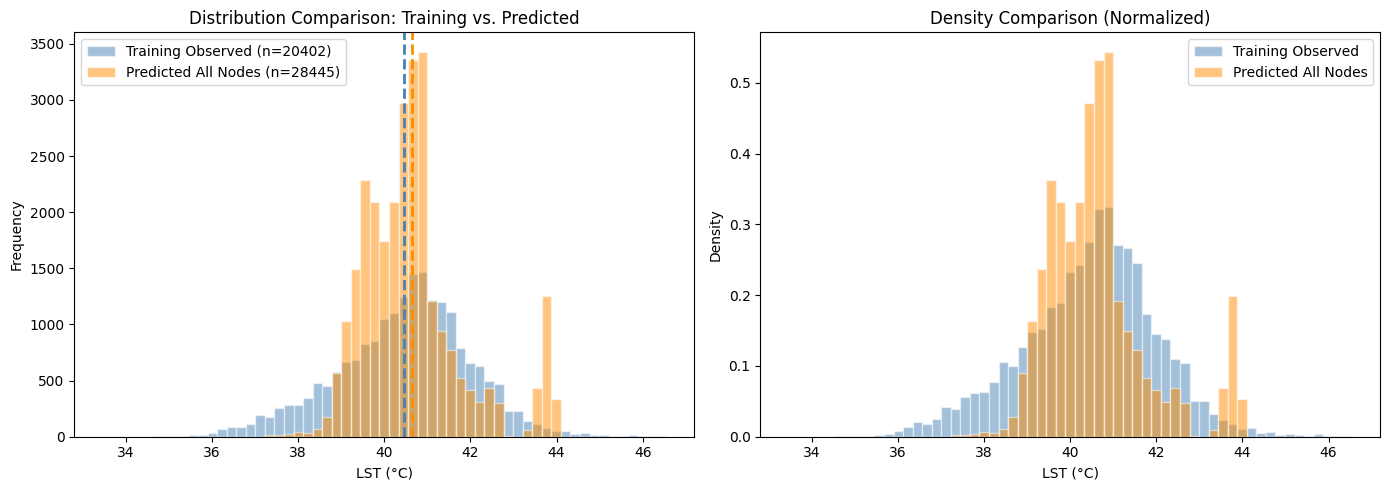

In [14]:
# Overlay histogram: training observed vs predicted distributions.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Overlapping histograms.
common_bins = np.linspace(
    min(train_lst.min(), pred_lst.min()),
    max(train_lst.max(), pred_lst.max()),
    60
)

axes[0].hist(train_lst, bins = common_bins, alpha = 0.5, color = "steelblue", edgecolor = "white", label = f"Training Observed (n={len(train_lst)})")
axes[0].hist(pred_lst, bins = common_bins, alpha = 0.5, color = "darkorange", edgecolor = "white", label = f"Predicted All Nodes (n={len(pred_lst)})")
axes[0].axvline(train_lst.mean(), color = "steelblue", linestyle = "--", lw = 2)
axes[0].axvline(pred_lst.mean(), color = "darkorange", linestyle = "--", lw = 2)
axes[0].set_xlabel("LST (\u00b0C)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution Comparison: Training vs. Predicted")
axes[0].legend()

# Normalized (density) overlay for shape comparison.
axes[1].hist(train_lst, bins = common_bins, alpha = 0.5, color = "steelblue", edgecolor = "white", density = True, label = "Training Observed")
axes[1].hist(pred_lst, bins = common_bins, alpha = 0.5, color = "darkorange", edgecolor = "white", density = True, label = "Predicted All Nodes")
axes[1].set_xlabel("LST (\u00b0C)")
axes[1].set_ylabel("Density")
axes[1].set_title("Density Comparison (Normalized)")
axes[1].legend()

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "distribution_density_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

## RESIDUAL SPATIAL MAP

Where observed LST is available (at network nodes with Landsat coverage), map the residual (observed - predicted) to identify spatial patterns in model error. Systematic over- or under-prediction in specific areas suggests the model is missing a spatially-varying factor.

Residual spatial map: 28340 nodes with both observed and predicted LST.
Residual stats: mean = 0.331, std = 1.381
Residual range: [-12.41, 26.03]


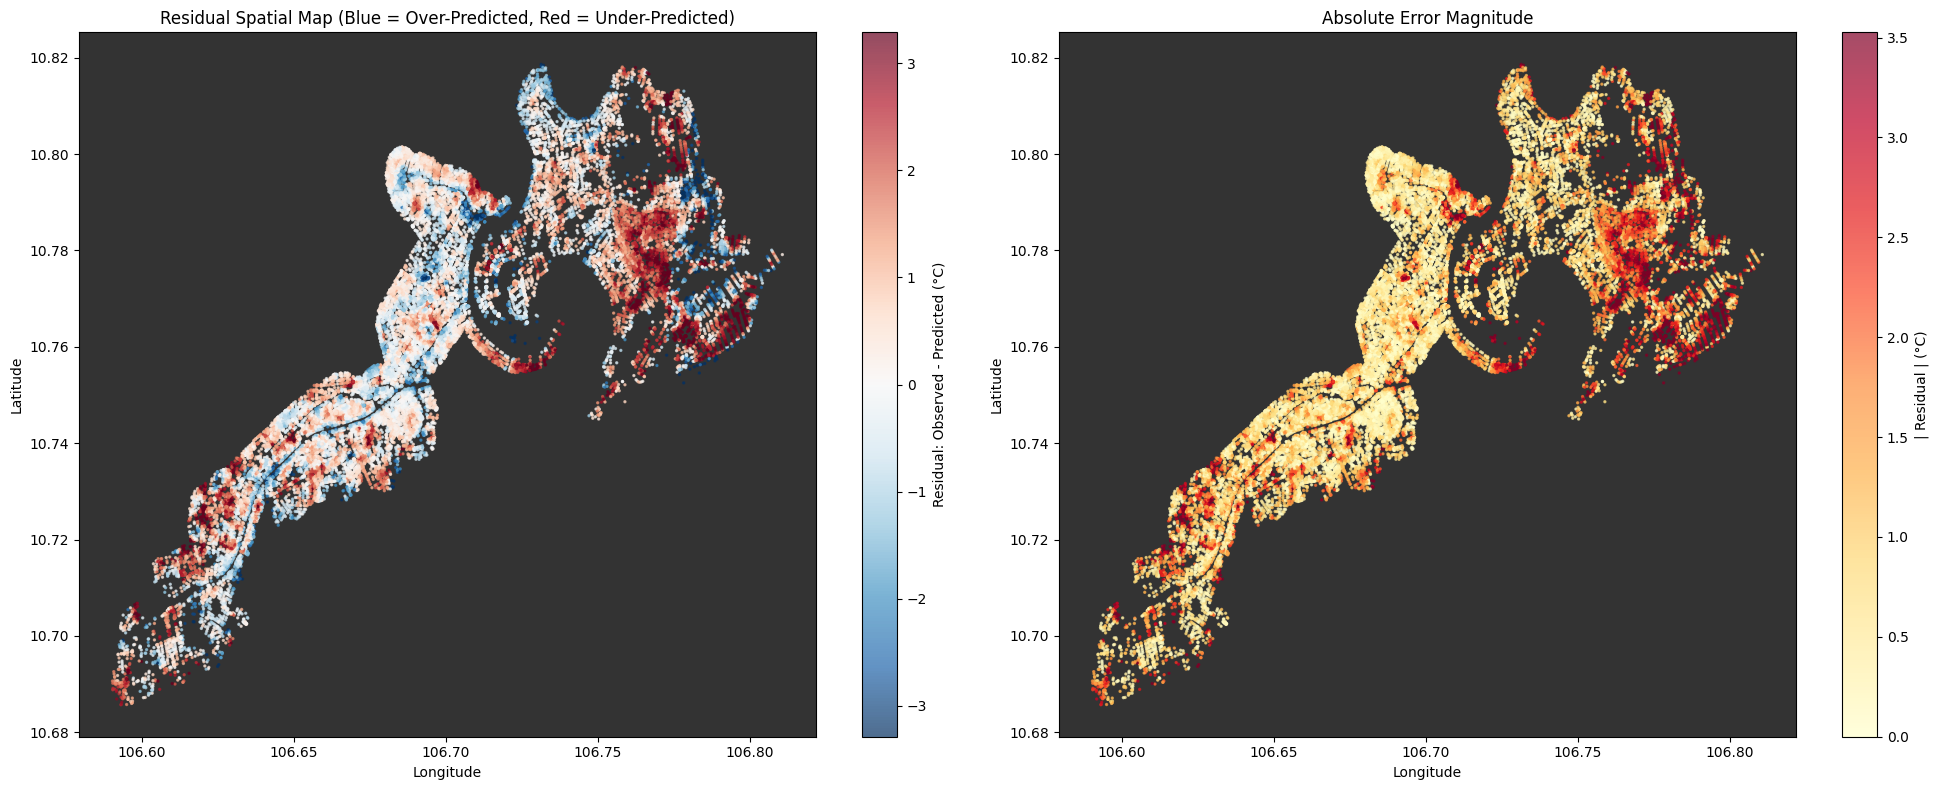


High-error nodes (top 10%, |residual| > 2.22 C): 2834
Mean absolute residual in high-error nodes: 3.17 C
Lat range: [10.6857, 10.8186]
Lon range: [106.5903, 106.8073]


In [15]:
if "lst_celsius" in df_nodes.columns and "lon" in df_nodes.columns and "lat" in df_nodes.columns:
    # Compute residuals where observed LST is available.
    residual_mask = df_nodes["lst_celsius"].notna() & df_nodes["predicted_lst_celsius"].notna()
    df_residual = df_nodes[residual_mask].copy()
    df_residual["residual"] = df_residual["lst_celsius"] - df_residual["predicted_lst_celsius"]

    print(f"Residual spatial map: {len(df_residual)} nodes with both observed and predicted LST.")
    print(f"Residual stats: mean = {df_residual['residual'].mean():.3f}, std = {df_residual['residual'].std():.3f}")
    print(f"Residual range: [{df_residual['residual'].min():.2f}, {df_residual['residual'].max():.2f}]")

    # Symmetric color limits centered on zero.
    vmax = max(abs(df_residual["residual"].quantile(0.02)), abs(df_residual["residual"].quantile(0.98)))

    fig, axes = plt.subplots(1, 2, figsize = (20, 8))

    # Panel 1: Residual map.
    axes[0].set_facecolor("#333333")
    sc1 = axes[0].scatter(
        df_residual["lon"],
        df_residual["lat"],
        c = df_residual["residual"],
        cmap = "RdBu_r",
        s = 2,
        alpha = 0.7,
        vmin = -vmax,
        vmax = vmax
    )
    plt.colorbar(sc1, ax = axes[0], label = "Residual: Observed - Predicted (\u00b0C)")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[0].set_title("Residual Spatial Map (Blue = Over-Predicted, Red = Under-Predicted)")

    # Panel 2: Absolute residual map (error magnitude).
    axes[1].set_facecolor("#333333")
    sc2 = axes[1].scatter(
        df_residual["lon"],
        df_residual["lat"],
        c = df_residual["residual"].abs(),
        cmap = "YlOrRd",
        s = 2,
        alpha = 0.7,
        vmin = 0,
        vmax = df_residual["residual"].abs().quantile(0.98)
    )
    plt.colorbar(sc2, ax = axes[1], label = "| Residual | (\u00b0C)")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    axes[1].set_title("Absolute Error Magnitude")

    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "residual_abs_error.png", dpi = 300, bbox_inches = "tight")
    plt.show()

    # Report high-error clusters.
    high_error_threshold = df_residual["residual"].abs().quantile(0.90)
    high_error = df_residual[df_residual["residual"].abs() > high_error_threshold]
    print(f"")
    print(f"High-error nodes (top 10%, |residual| > {high_error_threshold:.2f} C): {len(high_error)}")
    print(f"Mean absolute residual in high-error nodes: {high_error['residual'].abs().mean():.2f} C")
    print(f"Lat range: [{high_error['lat'].min():.4f}, {high_error['lat'].max():.4f}]")
    print(f"Lon range: [{high_error['lon'].min():.4f}, {high_error['lon'].max():.4f}]")
else:
    print("Observed LST or lat/lon columns not available for residual spatial map.")

## SAVE PREDICTIONS

In [16]:
# Save network nodes with predictions.
df_nodes.to_csv(OUT_FILE, index = False)

print("PREDICTIONS SAVED")
print(f"Output file: {OUT_FILE}")
print(f"Total nodes: {len(df_nodes)}")
print("Key Prediction Columns:")
print("predicted_lst_celsius: Predicted temperature for routing cost.")
print("heat_category: Quintile-based heat level for analysis.")

PREDICTIONS SAVED
Output file: data/outputs/predictions/network_nodes_with_predictions.csv
Total nodes: 28445
Key Prediction Columns:
predicted_lst_celsius: Predicted temperature for routing cost.
heat_category: Quintile-based heat level for analysis.


## SUMMARY

In [17]:
print("NODE PREDICTION SUMMARY")
print(f"Total network nodes: {len(df_nodes)}")
print(f"Nodes with predictions: {df_nodes['predicted_lst_celsius'].notna().sum()}")
print("")
print("Predicted LST Range:")
print(f"Min: {df_nodes['predicted_lst_celsius'].min():.2f}")
print(f"Max: {df_nodes['predicted_lst_celsius'].max():.2f}")
print(f"Mean: {df_nodes['predicted_lst_celsius'].mean():.2f}")
print(f"Std: {df_nodes['predicted_lst_celsius'].std():.2f}")
print("")
print("Heat Category Breakdown (Quintile-Based):")
for cat in quintile_labels:
    count = (df_nodes["heat_category"] == cat).sum()
    pct = count / len(df_nodes) * 100
    print(f"{cat:15s}: {count:6d} ({pct:5.1f}%)")

NODE PREDICTION SUMMARY
Total network nodes: 28445
Nodes with predictions: 28445

Predicted LST Range:
Min: 37.33
Max: 44.04
Mean: 40.64
Std: 1.20

Heat Category Breakdown (Quintile-Based):
Coolest 20%    :   5689 ( 20.0%)
Cool-Moderate  :   5689 ( 20.0%)
Moderate       :   5689 ( 20.0%)
Warm-Hot       :   5689 ( 20.0%)
Hottest 20%    :   5689 ( 20.0%)
